<a href="https://colab.research.google.com/github/ravi-asati/ravi-writes-abinitio-to-spark/blob/main/simple-graph-to-pyspark-script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# a whole graph &rarr; a whole script — try it live

Runnable companion to the note: **[Ab Initio Graph to PySpark Script](https://ravi-writes.pages.dev/notes/abinitio-to-pyspark/1-ab-initio-graph-to-pyspark-script)**.

Run the cells top to bottom.

## The data & the requirement

A pipe-delimited file, no header, two fields per line — `name` and `status`:

```
  Karen Hughes |A
 Brian Cole|I
```

The next cell generates it with plain Python and [Faker](https://faker.readthedocs.io/)
— **not** with Spark, so we aren't using Spark to create the very file we're about to
teach Spark to read. It's seeded, so you get the same rows every run.

Two things are deliberately planted:

- **Padded names.** Some rows carry leading/trailing spaces — fixed-width habits leaking
  into a delimited file. That's what the Reformat stage exists to clean.
- **Two statuses**, `A` (active) and `I` (inactive), roughly 50/50.

**Requirement:** read the file, **keep only the active customers**, **trim the whitespace
off their names**, and write the result out as a header-carrying file.

In [ ]:
# Generate the input file with plain Python + Faker (no Spark here on purpose)
!pip install -q faker

import os, random
from faker import Faker

fake = Faker()
Faker.seed(42)
random.seed(42)

INPUT_PATH = "/content/ravi-writes/data/input/customers.dat"
os.makedirs(os.path.dirname(INPUT_PATH), exist_ok=True)

with open(INPUT_PATH, "w", encoding="utf-8") as f:
    for _ in range(200):
        name = fake.name()
        # plant the mess: pad some names the way a fixed-width feed would
        pad_l = " " * random.choice([0, 0, 1, 2])
        pad_r = " " * random.choice([0, 0, 1, 3])
        status = random.choice(["A", "I"])
        f.write(f"{pad_l}{name}{pad_r}|{status}\n")

print(f"wrote {INPUT_PATH}")
print(f"{os.path.getsize(INPUT_PATH)} bytes\n")

# The shell is one ! away in Colab — look at what we actually wrote.
# cat -A marks end-of-line with $, the only way to SEE a trailing space.
!head -3 {INPUT_PATH} | cat -A
print("---- No of records in input dataset----")
!wc -l {INPUT_PATH}

# Only some rows are padded, and the first few aren't — so go find them.
padded = [l for l in open(INPUT_PATH) if l[0] == " " or " |" in l]
print(f"\n{len(padded)} of 200 rows carry padding. Brackets make it visible:")
for line in padded[:3]:
    shown = line.rstrip("\n")
    print(f"  [{shown}]")

## The Ab Initio solution

Six components in a straight line. Note where the **text/record boundary** sits: the
**Input File** reads bytes, **Read Separated Values** turns them into typed records, and
**Write Separated Values** turns records back into bytes. Everything in between works on
records.

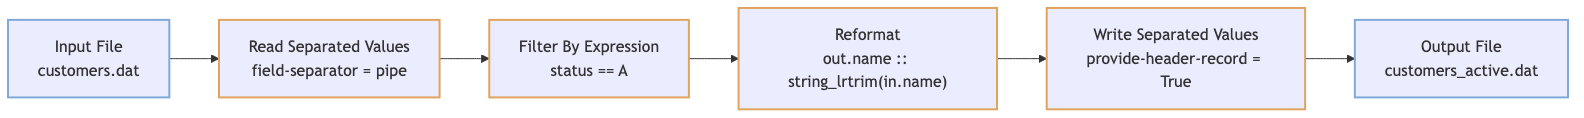

## The Spark solution — step by step

The same pipeline, in the order the graph runs it.

In [ ]:
# 1. Install PySpark (one-time, in Colab's runtime)
!pip install -q pyspark

In [ ]:
# 2. Imports & SparkSession — the one object every job starts from (the Co>Operating System)
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, types as T

spark = SparkSession.builder.appName("customer_load").getOrCreate()
print(spark.version)

In [ ]:
# 3. Input File + Read Separated Values -> spark.read
#    The schema IS the DML record format: two strings, in order.
INPUT_PATH = "/content/ravi-writes/data/input/customers.dat"

schema = T.StructType([
    T.StructField("name",   T.StringType()),
    T.StructField("status", T.StringType()),
])

df_read = (spark.read.format("csv")
    .options(lineSep="\n", sep="|", header=False)
    .schema(schema)
    .load(INPUT_PATH))

# This is your watcher
df_read.printSchema()
df_read.show(5, truncate=False)

In [ ]:
# 4. Filter By Expression -> df.filter
#    One boolean Column expression. Keeps the rows where it is TRUE.
df_filtered = df_read.filter(F.col("status") == "A")

# This is your watcher
df_filtered.show(5, truncate=False)

In [ ]:
# 5. Reformat -> df.select
#    out.name :: string_lrtrim(in.name);  ->  F.trim(F.col("name")).alias("name")
#    A select names every output field, exactly like a reformat transform.
df_write = df_filtered.select(
    F.trim(F.col("name")).alias("name"),
    F.col("status"),
)

# This is your watcher
df_write.show(5, truncate=False)

In [ ]:
# 6. Write Separated Values + Output File -> df.write
#    This is an ACTION — everything above was lazy until this line.
OUTPUT_PATH = "/content/ravi-writes/data/output/customers_active"

(df_write.write.format("csv")
    .options(lineSep="\n", sep="\x01", header=True)
    .mode("overwrite")
    .save(OUTPUT_PATH))

print(f"wrote {OUTPUT_PATH}")

In [ ]:
# 7. What actually landed on disk?
#    Spark writes a DIRECTORY of part-* files, not a single file — the multifile parallel.
!ls -la {OUTPUT_PATH}
print("---- the data ----")
!cat {OUTPUT_PATH}/part-*.csv | head -5
print("---- No of records in outout dataset----")
!wc -l {OUTPUT_PATH}/part-*.csv

In [ ]:
# 8. Done — release the cluster
spark.stop()

## Your turn

1. **Land a single file.** The write produced a directory of `part-*` files. Add
   `.coalesce(1)` before `.write` and look at the output again — what changed, and what
   did it cost you?
2. **Drop the schema.** Replace `.schema(schema)` with `.option("inferSchema", True)`.
   What are the column names now, and why?